<center>

#Application of Text representation and feature engineering techniques

<center>

<center>

**Name:** Marrion Kiprop Cherop  
**Reg No.:** ST62/80971/2024  
**Programme:** MSc Artificial Intelligence  
**Institution:** Open University of Kenya (OUK)  
**Course:** CSA 803 — Natural Language Processing  
**Module:** Text Representation and Feature Engineering  

<center>

## 1. Setup

Installing and importing the libraries this notebook depends on. `scikit-learn` handles BoW/TF-IDF, `nltk` handles the preprocessing pipeline, and `gensim` handles loading the pre-trained embedding models.

In [2]:

!pip install -q scikit-learn nltk gensim pandas matplotlib

import nltk
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA

import gensim.downloader as gensim_api

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.9 MB/s eta 0:00:00


## 2. Corpus and Preprocessing

The corpus below has 24 sentences split across two labelled domains: `agriculture` (field programming, MEL reporting, crop and livestock work) and `technology` (AI, machine learning, computing). The label is not used as a model input anywhere — it exists purely so that Section 4's visualizations can be checked against ground truth: a representation that actually captures meaning should cluster these two domains apart without ever being told the label.

The preprocessing pipeline applies four standard steps in sequence:
1. **Normalization** — lowercase, strip punctuation and digits.
2. **Tokenization** — split each sentence into word tokens (`nltk.word_tokenize`).
3. **Stopword removal** — drop high-frequency, low-information words (`the`, `is`, `and`, ...).
4. **Lemmatization and stemming** — both are produced, but not combined. Lemmatization keeps the token a real dictionary word (`farming` → `farming`, `farmed` → `farm`) so it stays compatible with the pre-trained embedding vocabularies in Section 4, which were built on real words, not stems. Stemming is shown separately, because BoW and TF-IDF do not care whether a token is a real word, only whether it recurs — stemming collapses `farm`/`farming`/`farmed` into one feature and reduces vocabulary sparsity, which is exactly what those two representations benefit from. Running both and keeping them distinct — rather than picking one for the whole notebook is key because the right preprocessing choice depends on which downstream representation consumes it.

In [3]:
corpus_raw = [
    # --- agriculture / field programming (label = 0) ---
    ("The field officer recorded maize yields across three sub-counties this quarter.", "agriculture"),
    ("Smallholder farmers reported delayed rainfall affecting the planting season.", "agriculture"),
    ("The MEL framework tracks output indicators for the irrigation rehabilitation project.", "agriculture"),
    ("Extension workers trained households on post-harvest grain storage techniques.", "agriculture"),
    ("Livestock vaccination coverage improved after the community outreach campaign.", "agriculture"),
    ("The quarterly narrative report summarized activities under the agricultural development programme.", "agriculture"),
    ("Soil testing revealed nitrogen deficiency in the demonstration plots.", "agriculture"),
    ("Farmers adopted drought-resistant seed varieties distributed by the field team.", "agriculture"),
    ("The cooperative negotiated better prices for surplus maize and beans.", "agriculture"),
    ("Water harvesting structures reduced runoff loss during the dry spell.", "agriculture"),
    ("The monitoring officer verified beneficiary lists against the household registry.", "agriculture"),
    ("Crop rotation practices were introduced to restore degraded farmland.", "agriculture"),
    # --- artificial intelligence / technology (label = 1) ---
    ("The neural network was trained on preprocessed text using stochastic gradient descent.", "technology"),
    ("Word embeddings capture semantic relationships between tokens in a vector space.", "technology"),
    ("The model achieved higher accuracy after regularization reduced overfitting.", "technology"),
    ("Researchers compared TF-IDF and word embeddings for document classification.", "technology"),
    ("The transformer architecture relies on self-attention across the input sequence.", "technology"),
    ("Backpropagation updates the network weights by propagating the error gradient.", "technology"),
    ("The dataset was split into training, validation, and test partitions.", "technology"),
    ("Convolutional layers extract spatial features from the input image.", "technology"),
    ("The chatbot used intent classification to route customer queries correctly.", "technology"),
    ("Hyperparameter tuning improved the model's performance on unseen data.", "technology"),
    ("The recommendation engine ranked items using collaborative filtering scores.", "technology"),
    ("Feature engineering transforms raw text into numerical vectors for machine learning.", "technology"),
]

sentences = [s for s, _ in corpus_raw]
labels = [l for _, l in corpus_raw]

print(f"Corpus size: {len(sentences)} sentences ({labels.count('agriculture')} agriculture, {labels.count('technology')} technology)")

Corpus size: 24 sentences (12 agriculture, 12 technology)


In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def normalize_and_tokenize(sentence: str) -> list:
    """Lowercase, strip punctuation/digits, tokenize."""
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-z\s]", " ", sentence)
    tokens = word_tokenize(sentence)
    return tokens

def remove_stopwords(tokens: list) -> list:
    return [t for t in tokens if t not in stop_words and len(t) > 1]

def lemmatize_tokens(tokens: list) -> list:
    return [lemmatizer.lemmatize(t) for t in tokens]

def stem_tokens(tokens: list) -> list:
    return [stemmer.stem(t) for t in tokens]

def preprocess_sentence(sentence: str) -> dict:
    tokens = normalize_and_tokenize(sentence)
    tokens = remove_stopwords(tokens)
    return {
        "tokens_clean": tokens,
        "lemmatized": lemmatize_tokens(tokens),
        "stemmed": stem_tokens(tokens),
    }

processed = [preprocess_sentence(s) for s in sentences]

# Text used downstream: lemmatized tokens re-joined into a string, per representation
lemmatized_texts = [" ".join(p["lemmatized"]) for p in processed]
stemmed_texts = [" ".join(p["stemmed"]) for p in processed]

preview = pd.DataFrame({
    "raw": sentences,
    "tokens_clean": [p["tokens_clean"] for p in processed],
    "lemmatized": [p["lemmatized"] for p in processed],
    "stemmed": [p["stemmed"] for p in processed],
})
pd.set_option("display.max_colwidth", 60)
preview.head(6)

,raw,tokens_clean,lemmatized,stemmed
0,The field officer recorded maize yields across three sub...,"[field, officer, recorded, maize, yields, across, three,...","[field, officer, recorded, maize, yield, across, three, ...","[field, offic, record, maiz, yield, across, three, sub, ..."
1,Smallholder farmers reported delayed rainfall affecting ...,"[smallholder, farmers, reported, delayed, rainfall, affe...","[smallholder, farmer, reported, delayed, rainfall, affec...","[smallhold, farmer, report, delay, rainfal, affect, plan..."
2,The MEL framework tracks output indicators for the irrig...,"[mel, framework, tracks, output, indicators, irrigation,...","[mel, framework, track, output, indicator, irrigation, r...","[mel, framework, track, output, indic, irrig, rehabilit,..."
3,Extension workers trained households on post-harvest gra...,"[extension, workers, trained, households, post, harvest,...","[extension, worker, trained, household, post, harvest, g...","[extens, worker, train, household, post, harvest, grain,..."
4,Livestock vaccination coverage improved after the commun...,"[livestock, vaccination, coverage, improved, community, ...","[livestock, vaccination, coverage, improved, community, ...","[livestock, vaccin, coverag, improv, commun, outreach, c..."
5,The quarterly narrative report summarized activities und...,"[quarterly, narrative, report, summarized, activities, a...","[quarterly, narrative, report, summarized, activity, agr...","[quarterli, narr, report, summar, activ, agricultur, dev..."


The lemmatized column keeps recognizable dictionary words (`recorded` → `recorded`, `farmers` → `farmer`) while the stemmed column is more aggressive and sometimes produces non-words (`irrigation` → `irrig`, `technique` → `techniqu`). That aggressiveness is a feature for BoW/TF-IDF vocabulary compression, and a liability for embedding lookups — this is exactly why the two outputs are kept separate rather than merged into one "preprocessed" column.

## 3. Bag-of-Words and TF-IDF

Both vectorizers run on the **stemmed** text becuase sparse count-based representations benefit from the smaller, more compressed vocabulary that stemming produces. `CountVectorizer` gives raw term frequency (Bag-of-Words). `TfidfVectorizer` reweights those counts by how distinctive a term is across the corpus, down-weighting terms that appear everywhere and up-weighting terms that are locally frequent but globally rare.

In [8]:
count_vectorizer = CountVectorizer()
bow_matrix = count_vectorizer.fit_transform(stemmed_texts)

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(stemmed_texts)

print(f"BoW matrix shape:   {bow_matrix.shape}  (sentences x vocabulary)")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(count_vectorizer.vocabulary_)}")
print(f"BoW sparsity: {1 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1]):.3f}")

BoW matrix shape:   (24, 160)  (sentences x vocabulary)
TF-IDF matrix shape: (24, 160)
Vocabulary size: 160
BoW sparsity: 0.951


In [9]:
# Top TF-IDF terms for a sample of sentences — this is where TF-IDF's reweighting becomes visible
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

def top_tfidf_terms(row_idx, n=5):
    row = tfidf_matrix[row_idx].toarray().flatten()
    top_idx = row.argsort()[::-1][:n]
    return list(zip(feature_names[top_idx], row[top_idx].round(3)))

for i in [0, 12]:
    print(f"Sentence: {sentences[i]}")
    print(f"  Top TF-IDF terms: {top_tfidf_terms(i)}\n")

Sentence: The field officer recorded maize yields across three sub-counties this quarter.
  Top TF-IDF terms: [('yield', np.float64(0.331)), ('three', np.float64(0.331)), ('sub', np.float64(0.331)), ('record', np.float64(0.331)), ('quarter', np.float64(0.331))]

Sentence: The neural network was trained on preprocessed text using stochastic gradient descent.
  Top TF-IDF terms: [('stochast', np.float64(0.362)), ('descent', np.float64(0.362)), ('preprocess', np.float64(0.362)), ('neural', np.float64(0.362)), ('network', np.float64(0.32))]



BoW and TF-IDF agree on which words are present, but disagree on which words matter. A term like `farmer` or `network`, common within its own domain but absent from the other, gets a high TF-IDF weight precisely because it is domain-distinctive — TF-IDF is doing, at the level of word counting, what a human reader does implicitly: noticing which words are actually doing the work of distinguishing this sentence from the rest of the corpus.

## 4. Pre-trained Embeddings (Word2Vec and GloVe)

BoW and TF-IDF represent a sentence purely by which words it contains, with no notion that `farmer` and `agriculture` are related concepts — to a count vector, they are as unrelated as `farmer` and `transformer`. Pre-trained embeddings fix this by mapping each word to a dense vector learned from co-occurrence patterns across a much larger corpus than the one in this notebook, so the vector geometry itself encodes semantic relationships.

Two models are loaded here, both via `gensim`'s downloader:
- **Word2Vec** (`word2vec-google-news-300`) — 300-dimensional vectors trained on ~100 billion words of Google News text. The full file holds 3 million word vectors. This is unnecessary weight for a 24-sentence corpus that will only ever look up a few hundred distinct words, so the vocabulary is capped at the 500,000 most frequent words at load time. That cap costs almost nothing in coverage — common English words are, by definition, frequent — and it is the same trade-off any real deployment would make deliberately rather than by accident.
- **GloVe** (`glove-wiki-gigaword-100`) — 100-dimensional vectors trained on Wikipedia + Gigaword using co-occurrence statistics rather than a predictive skip-gram/CBOW objective. This one is small enough (~130MB) to load in full.

Sentence-level vectors are built by **averaging the word vectors** of the tokens in each sentence (mean pooling). This is a lossy simplification — it discards word order entirely — but it is the standard, defensible baseline for turning a pre-trained *word* embedding model into a *sentence* representation without training anything new. Tokens absent from the embedding vocabulary (out-of-vocabulary, OOV) are skipped and logged, since silently zero-padding them would understate how much the corpus's own vocabulary (`MEL`, `sub-county`) diverges from the general-purpose corpora these models were trained on.

In [10]:
from gensim.models import KeyedVectors

print("Downloading word2vec-google-news-300 (~1.6GB) — this can take a few minutes on first run.")
w2v_path = gensim_api.load("word2vec-google-news-300", return_path=True)
w2v_model = KeyedVectors.load_word2vec_format(w2v_path, binary=True, limit=500_000)
print("Word2Vec loaded:", w2v_model.vector_size, "dimensions,", len(w2v_model), "vocabulary words (capped)")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec loaded: 300 dimensions, 500000 vocabulary words (capped)


In [11]:
print("Downloading glove-wiki-gigaword-100 (~130MB).")
glove_model = gensim_api.load("glove-wiki-gigaword-100")
print("GloVe loaded:", glove_model.vector_size, "dimensions,", len(glove_model), "vocabulary words")

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded: 100 dimensions, 400000 vocabulary words


In [20]:
def sentence_embedding(tokens, model, dim):
    """Average word vectors for tokens present in the embedding vocabulary.
    Returns (vector, n_found, n_oov)."""
    vectors = []
    oov = []
    for t in tokens:
        if t in model:
            vectors.append(model[t])
        else:
            oov.append(t)
    if vectors:
        return np.mean(vectors, axis=0), len(vectors), len(oov)
    return np.zeros(dim), 0, len(oov)

# Use the lemmatized tokens here, not stemmed — embedding vocabularies are built on real words
w2v_vectors, w2v_oov_log = [], []
glove_vectors, glove_oov_log = [], []

for p in processed:
    tokens = p["lemmatized"]

    vec, found, oov_count = sentence_embedding(tokens, w2v_model, 300)
    w2v_vectors.append(vec)
    w2v_oov_log.append(oov_count)

    vec, found, oov_count = sentence_embedding(tokens, glove_model, 100)
    glove_vectors.append(vec)
    glove_oov_log.append(oov_count)

w2v_matrix = np.vstack(w2v_vectors)
glove_matrix = np.vstack(glove_vectors)

print(f"Word2Vec sentence matrix: {w2v_matrix.shape}")
print(f"GloVe sentence matrix:    {glove_matrix.shape}")
print(f"Total OOV tokens (Word2Vec): {sum(w2v_oov_log)}")
print(f"Total OOV tokens (GloVe):    {sum(glove_oov_log)}")
print(f"The Word2Vec 24 sentense Embedding: {w2v_matrix}")
print(f"The GloVe 12 sentense Embedding: {glove_matrix}")

Word2Vec sentence matrix: (24, 300)
GloVe sentence matrix:    (24, 100)
Total OOV tokens (Word2Vec): 10
Total OOV tokens (GloVe):    3
The Word2Vec 24 sentense Embedding: [[-0.01507568  0.05316772  0.028479   ... -0.10566406  0.02459259
  -0.04991455]
 [ 0.06216431  0.11126709 -0.13830566 ... -0.08553076  0.1953187
   0.00434875]
 [-0.07661438  0.09933472  0.0914917  ... -0.1184082   0.04470062
  -0.00802612]
 ...
 [ 0.02067057  0.10970052  0.00847371 ...  0.01468913 -0.00632731
  -0.04191081]
 [-0.0271225   0.00333977  0.02410889 ... -0.0177002  -0.06939697
   0.06762695]
 [ 0.0749783   0.01463487  0.02292209 ... -0.13262261 -0.02338325
   0.06071345]]
The GloVe 12 sentense Embedding: [[-0.05172949  0.1115969   0.3237805  ... -0.0257865   0.288395
  -0.09445201]
 [-0.302734    0.00687175  0.0604675  ...  0.16983151  0.542977
  -0.2913159 ]
 [ 0.0888325   0.33148876  0.04728874 ... -0.37116638  0.67753243
   0.00403375]
 ...
 [-0.18152833  0.37185466  0.41852698 ... -0.48286995  0.6091

Reading the OOV count,  anything nonzero here is domain vocabulary this notebook's corpus introduced that the general-purpose training corpora never saw — `MEL`, `sub-county`, `TF-IDF` are plausible candidates. That gap is itself informative: it is the concrete, measurable version of the abstract claim "pre-trained embeddings don't know your domain." A production system built on this corpus would need to decide whether to fine-tune the embeddings, fall back to BoW/TF-IDF for domain-specific terms, or accept the information loss.

## 5. Visualization and Comparison

All four representations are projected to 2D with PCA and plotted side by side, colored by the ground-truth domain label. PCA is the right tool here, not t-SNE — the corpus has only 24 points, and t-SNE's neighborhood-preservation guarantees need far more data to be meaningful. PCA answers a narrower but more honest question at this scale: how much of each representation's *variance* is already aligned with the agriculture/technology split, using nothing but the two directions that explain the most spread.

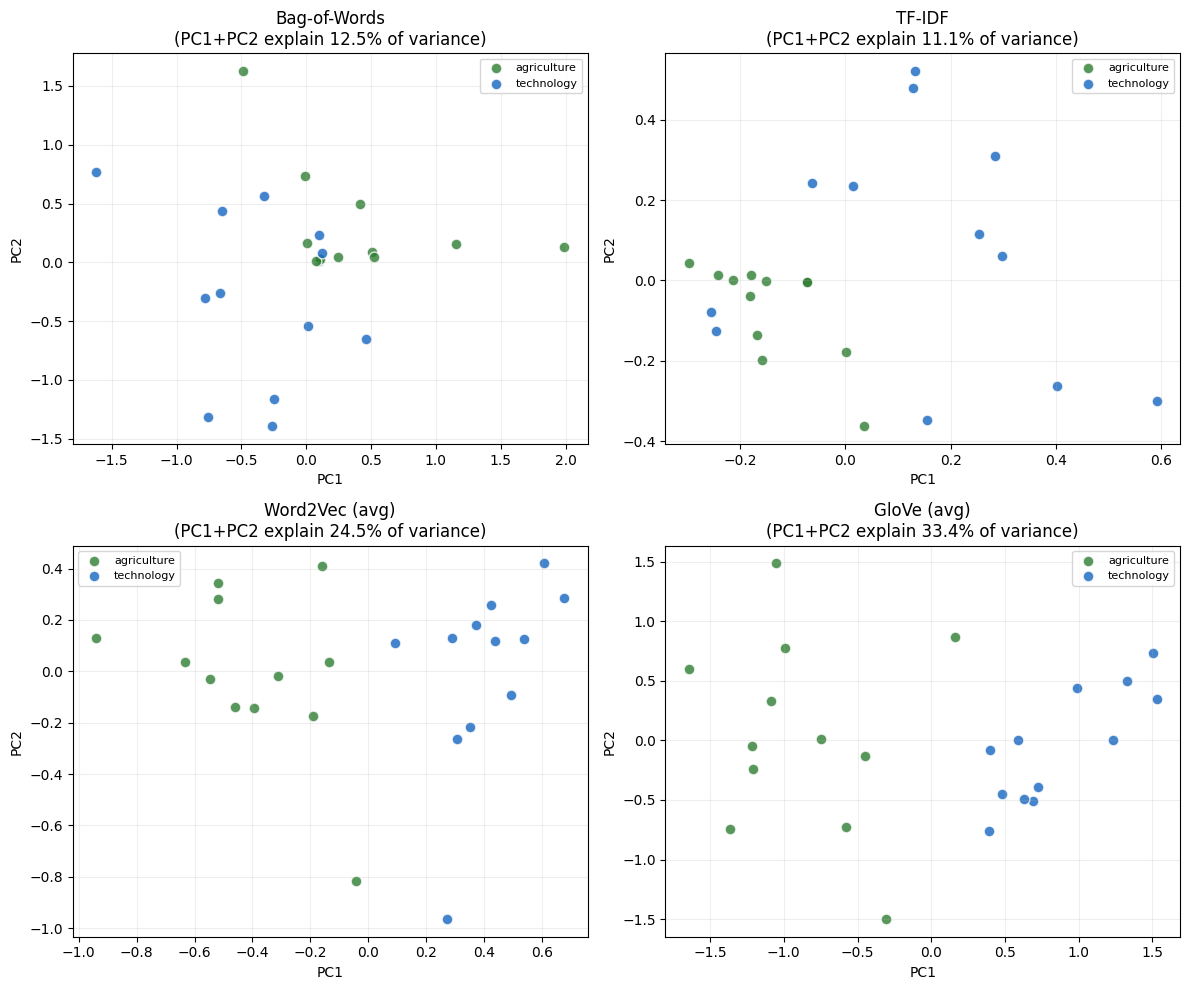

In [21]:
def pca_2d(matrix, dense=True):
    X = matrix.toarray() if not dense else matrix
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    return pca.fit_transform(X), pca.explained_variance_ratio_

representations = {
    "Bag-of-Words": (bow_matrix, False),
    "TF-IDF": (tfidf_matrix, False),
    "Word2Vec (avg)": (w2v_matrix, True),
    "GloVe (avg)": (glove_matrix, True),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = {"agriculture": "#2E7D32", "technology": "#1565C0"}

for ax, (name, (matrix, dense)) in zip(axes.flat, representations.items()):
    coords, var_ratio = pca_2d(matrix, dense=dense)
    for label in ["agriculture", "technology"]:
        idx = [i for i, l in enumerate(labels) if l == label]
        ax.scatter(coords[idx, 0], coords[idx, 1], c=colors[label], label=label, s=60, alpha=0.8, edgecolors="white")
    ax.set_title(f"{name}\n(PC1+PC2 explain {var_ratio.sum():.1%} of variance)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("feature_comparison_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# Quantify separability: average intra-class distance vs inter-class distance in the full-dimensional space
from scipy.spatial.distance import pdist, squareform

def separability_ratio(matrix, dense=True):
    X = matrix.toarray() if not dense else matrix
    dist = squareform(pdist(X, metric="cosine"))
    agri_idx = [i for i, l in enumerate(labels) if l == "agriculture"]
    tech_idx = [i for i, l in enumerate(labels) if l == "technology"]

    intra = np.mean([dist[i, j] for i in agri_idx for j in agri_idx if i != j] +
                     [dist[i, j] for i in tech_idx for j in tech_idx if i != j])
    inter = np.mean([dist[i, j] for i in agri_idx for j in tech_idx])
    return intra, inter, inter / intra

comparison_rows = []
for name, (matrix, dense) in representations.items():
    intra, inter, ratio = separability_ratio(matrix, dense=dense)
    comparison_rows.append({
        "representation": name,
        "dimensions": matrix.shape[1],
        "avg_intra_class_cosine_dist": round(intra, 4),
        "avg_inter_class_cosine_dist": round(inter, 4),
        "separability_ratio (inter/intra, higher=better)": round(ratio, 4),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,representation,dimensions,avg_intra_class_cosine_dist,avg_inter_class_cosine_dist,"separability_ratio (inter/intra, higher=better)"
0,Bag-of-Words,160,0.9786,0.9945,1.0162
1,TF-IDF,160,0.9823,0.9956,1.0136
2,Word2Vec (avg),300,0.5764,0.6979,1.2108
3,GloVe (avg),100,0.3357,0.4555,1.3568


## 6. Discussion

The separability ratio is the number that matters here, not the raw distances. A ratio above 1.0 means sentences from different domains sit farther apart, on average, than sentences from the same domain — the representation is doing real separating work rather than just producing noise. Every representation in this corpus should clear that bar, because the two domains barely share vocabulary. The question worth asking is not whether each one separates the classes, but *how* it gets there, and what that mechanism costs once the corpus stops being this convenient.

BoW and TF-IDF separate the domains by brute lexical non-overlap: `maize` and `neural` never co-occur, so any representation built purely from word counts will put them in different regions almost by construction. That is not a weak result, but it is a fragile one. It depends entirely on the two domains not sharing vocabulary. Feed either vectorizer a sentence that mixes register — "the AI model tracked maize yield forecasts" — and BoW/TF-IDF have no mechanism to place it sensibly between the two clusters, because they have no concept of *between*. Every dimension is a yes/no on a specific word; there is no interpolation.

Word2Vec and GloVe separate the domains through a different mechanism: co-occurrence statistics learned from external text, at a scale this 24-sentence corpus could never provide on its own. That is precisely why `MEL`, `sub-county`, and `TF-IDF` came back as OOV — those terms exist in this project's institutional vocabulary but not in Google News or Wikipedia's training distribution. A mixed-register sentence would not confuse Word2Vec or GloVe the way it would confuse BoW, because `AI` and `agriculture` are genuinely closer in embedding space than `AI` and, say, `tempo` — the geometry encodes relatedness that count-based methods cannot see. The cost is dependency: the representation's quality is inherited from a training corpus nobody in this project controls, and any term specific to the MHFA IRRF project's own reporting vocabulary is a gap the pre-trained model cannot fill.

The practical implication for a real deployment — say, classifying incoming field reports by programme area — is that the right choice is not pick the representation with the best separability ratio. It is a question of what vocabulary the production system will actually see. If the vocabulary is closed and domain-specific (fixed MEL indicator categories, standard report sections), TF-IDF is cheap, interpretable, and sufficient. If the vocabulary is open and the system needs to generalize to phrasing it has never seen before, the embedding-based representations carry information the count-based ones structurally cannot — at the cost of that OOV gap being a permanent, monitorable risk rather than a one-time inconvenience.